## **Análise Exploratória de Dados — Churn em E-commerce**

**Contexto de negócio:**  
Identificar precocemente clientes com alta probabilidade de cancelamento (churn) para permitir ações de retenção proativas e personalizadas por segmento de risco.

**Dataset:** Dados sintéticos baseados em padrões reais de e-commerce brasileiro — 10.000 clientes e ~72.000 transações.

#### Objetivos
1. Entender o perfil demográfico e de aquisição dos clientes
2. Analisar padrões de comportamento de compra por status de churn
3. Identificar os principais fatores associados ao cancelamento
4. Definir estratégia de feature engineering para a modelagem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Caminhos
DATA_DIR    = Path('../data/raw')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Paleta
COR_CHURN   = '#E74C3C'
COR_OK      = '#2ECC71'
COR_ACCENT  = '#2980B9'
COR_NEUTRO  = '#2C3E50'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'        : 150,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

def save_fig(name: str):
    path = FIGURES_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Salvo: {path}')
    plt.show()
    plt.close()

## **Carregamento e Qualidade dos Dados:**

In [2]:
clientes   = pd.read_csv(DATA_DIR / 'clientes.csv')
transacoes = pd.read_csv(DATA_DIR / 'transacoes.csv')
transacoes['data_compra'] = pd.to_datetime(transacoes['data_compra'])
clientes['data_cadastro'] = pd.to_datetime(clientes.get('data_cadastro', pd.NaT))

print(f'Clientes  : {clientes.shape[0]:,} linhas × {clientes.shape[1]} colunas')
print(f'Transações: {transacoes.shape[0]:,} linhas × {transacoes.shape[1]} colunas')
print(f'\nTaxa de churn: {clientes["churn"].mean():.2%}')
print(f'Período: {transacoes["data_compra"].min().date()} a {transacoes["data_compra"].max().date()}')

print('\nValores nulos — Clientes')
print(clientes.isnull().sum())
print('\nValores nulos — Transações')
print(transacoes.isnull().sum())

clientes.head()

Clientes  : 10,000 linhas × 7 colunas
Transações: 72,294 linhas × 5 colunas

Taxa de churn: 22.26%
Período: 2020-01-03 a 2026-06-05

Valores nulos — Clientes
id_cliente             0
idade                  0
genero                 0
cidade                 0
canal_aquisicao        0
churn                  0
data_cadastro      10000
dtype: int64

Valores nulos — Transações
id_cliente          0
data_compra         0
valor               0
categoria           0
metodo_pagamento    0
dtype: int64


,id_cliente,idade,genero,cidade,canal_aquisicao,churn,data_cadastro
0,1,40,F,RJ,Google,0,NaT
1,2,33,F,RJ,Google,0,NaT
2,3,42,M,SP,Indicação,0,NaT
3,4,53,M,BH,Orgânico,1,NaT
4,5,32,M,BH,Orgânico,1,NaT


## **Distribuição do Churn:**

Salvo: ..\figures\01_distribuicao_churn.png


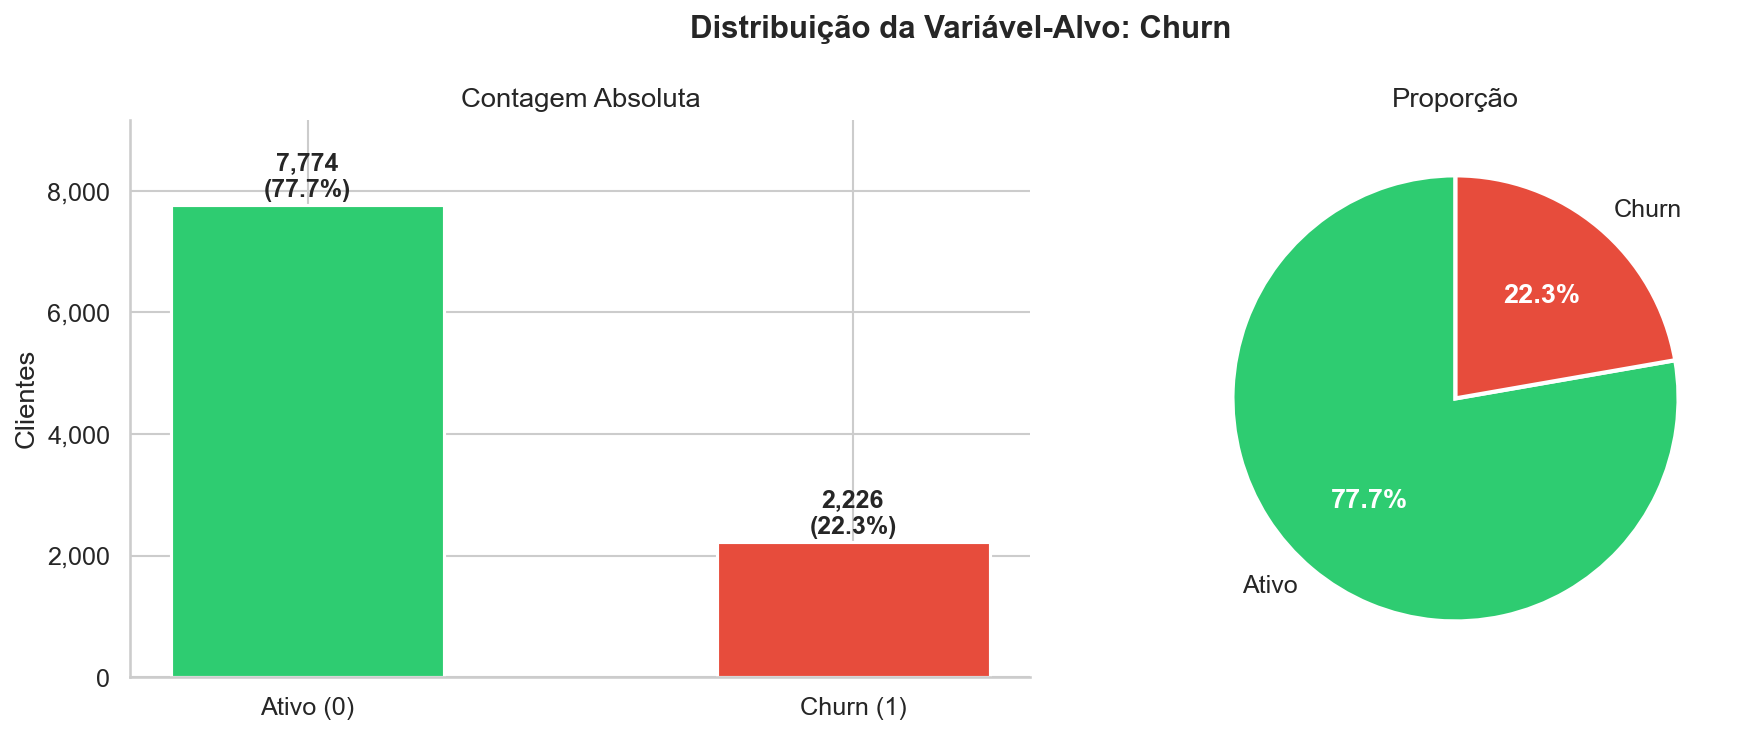

In [3]:
contagem   = clientes['churn'].value_counts()
proporcoes = clientes['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribuição da Variável-Alvo: Churn', fontsize=15, fontweight='bold')

ax = axes[0]
bars = ax.bar(['Ativo (0)', 'Churn (1)'], contagem.values,
              color=[COR_OK, COR_CHURN], width=0.5,
              edgecolor='white', linewidth=1.5)
for bar, val, pct in zip(bars, contagem.values, proporcoes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_ylabel('Clientes')
ax.set_title('Contagem Absoluta')
ax.set_ylim(0, contagem.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

ax = axes[1]
wedges, texts, autotexts = ax.pie(
    contagem.values, labels=['Ativo', 'Churn'],
    colors=[COR_OK, COR_CHURN], autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':12}
)
for at in autotexts:
    at.set(fontsize=13, fontweight='bold', color='white')
ax.set_title('Proporção')

plt.tight_layout()
save_fig('01_distribuicao_churn')

## **Churn por Variáveis Categóricas:**

Salvo: ..\figures\02_churn_categoricas.png


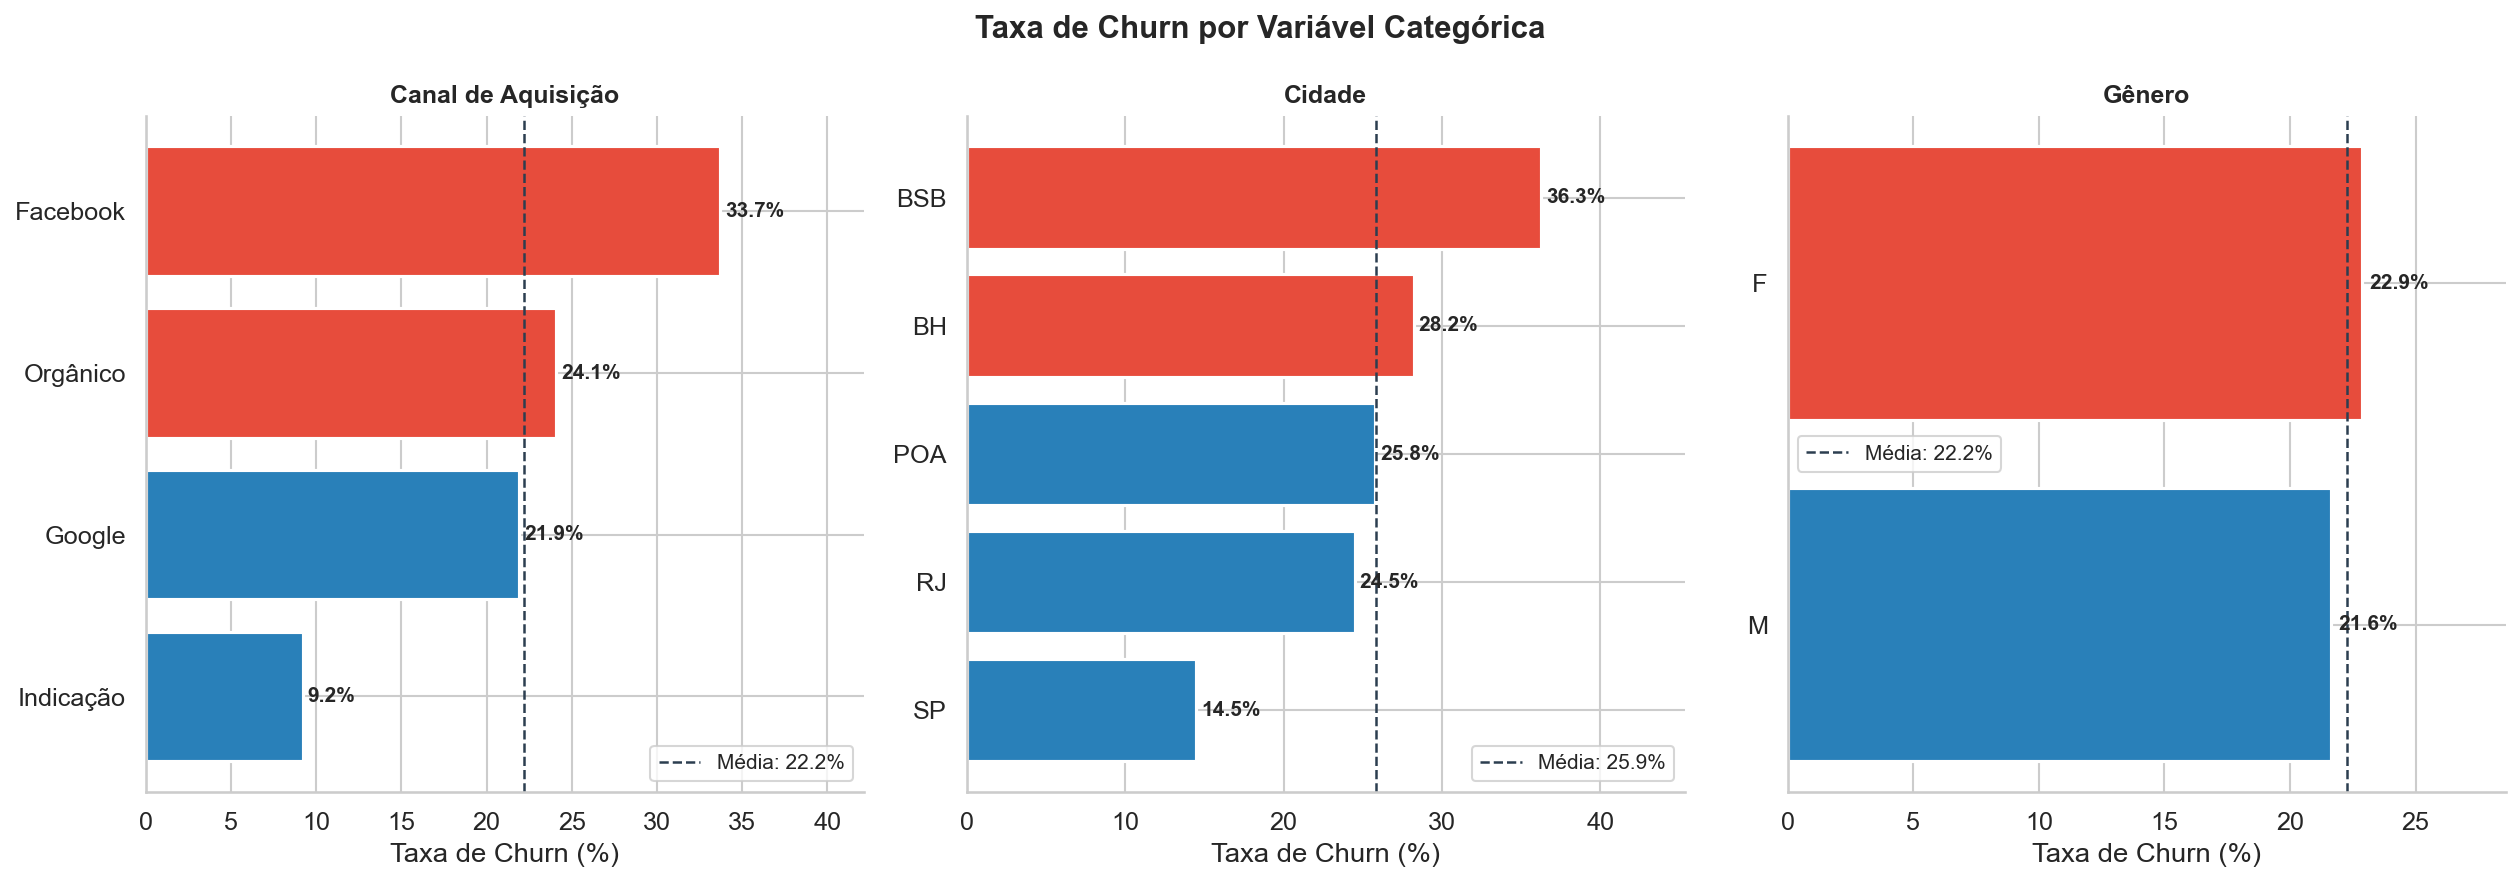

In [4]:
cats = [
    ('canal_aquisicao', 'Canal de Aquisição'),
    ('cidade',          'Cidade'),
    ('genero',          'Gênero'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Taxa de Churn por Variável Categórica', fontsize=15, fontweight='bold')

for ax, (col, titulo) in zip(axes, cats):
    taxas = (clientes.groupby(col)['churn'].mean() * 100).sort_values(ascending=True)
    cores = [COR_CHURN if v > taxas.mean() else COR_ACCENT for v in taxas.values]
    bars  = ax.barh(taxas.index, taxas.values, color=cores,
                    edgecolor='white', linewidth=1.5)
    media = taxas.mean()
    ax.axvline(media, color=COR_NEUTRO, linestyle='--', linewidth=1.2,
               label=f'Média: {media:.1f}%')
    for bar, val in zip(bars, taxas.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Taxa de Churn (%)')
    ax.legend(fontsize=10)
    ax.set_xlim(0, taxas.max() * 1.25)

plt.tight_layout()
save_fig('02_churn_categoricas')

# Salvar variáveis globais para uso em outros notebooks
churn_canal  = clientes.groupby('canal_aquisicao')['churn'].mean() * 100
churn_cidade = clientes.groupby('cidade')['churn'].mean() * 100

## **Churn por Faixa Etária:**

Salvo: ..\figures\03_churn_idade.png


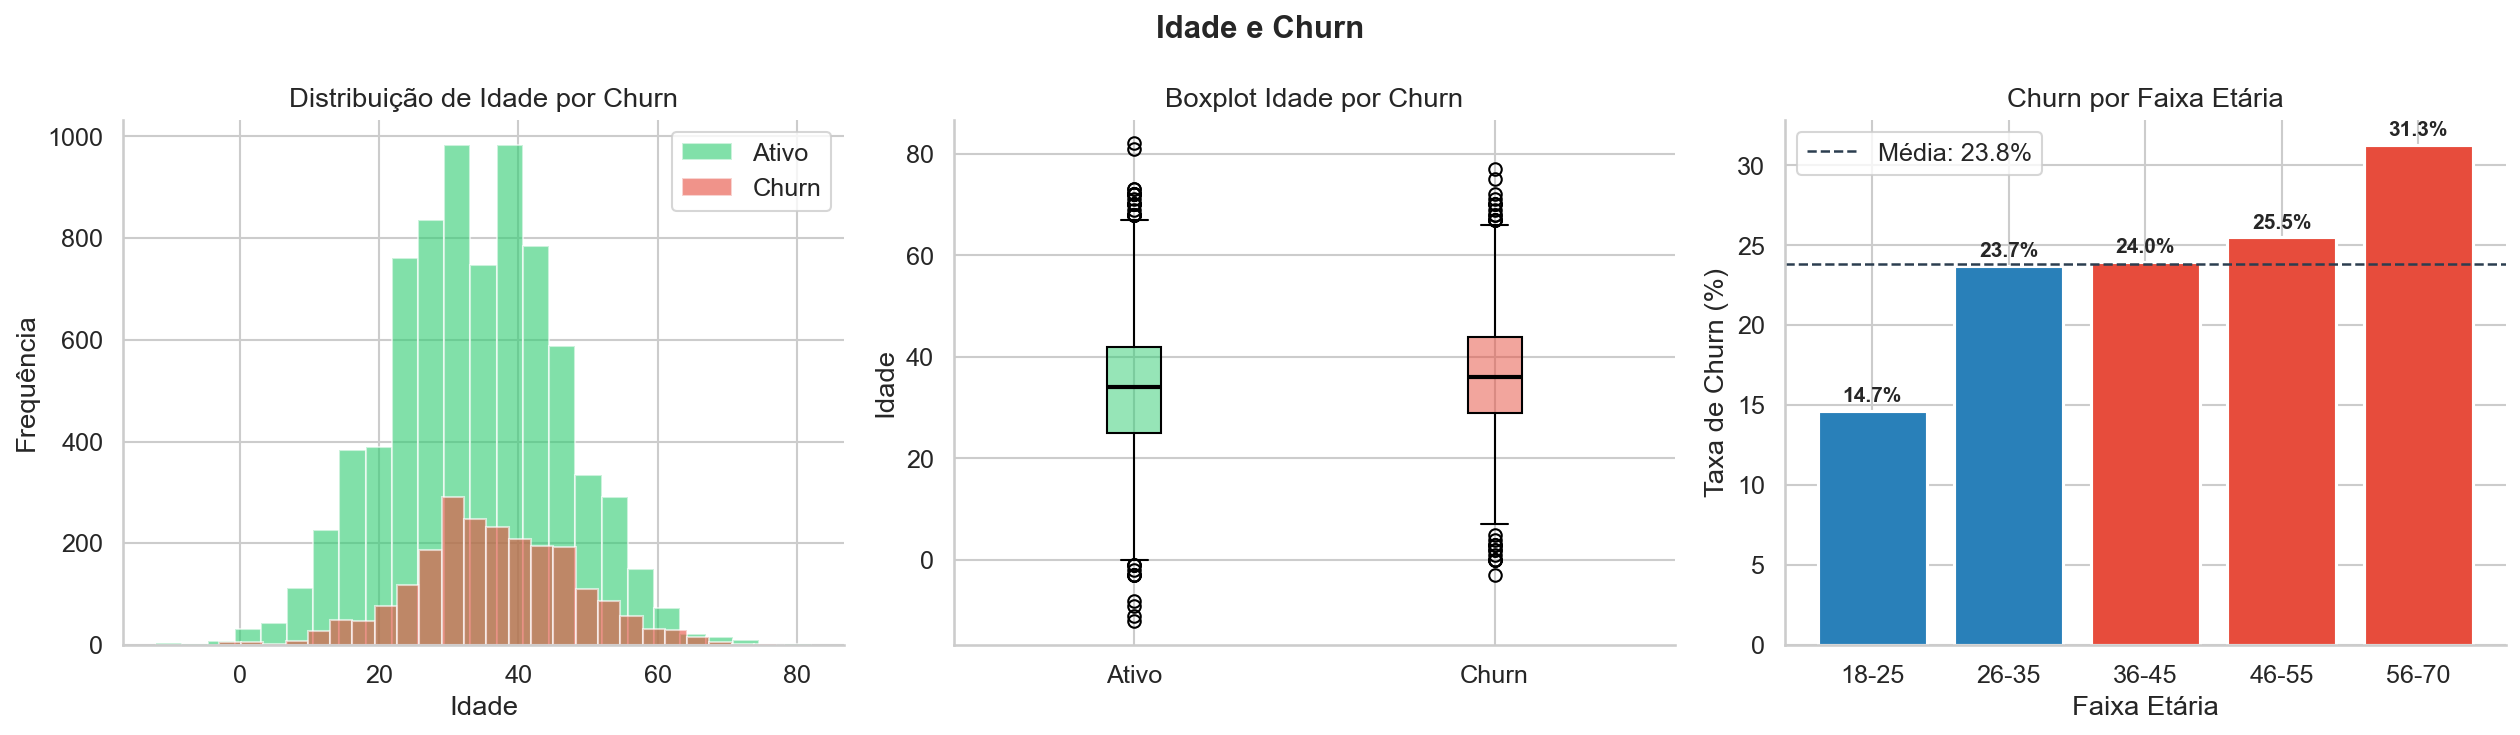

In [5]:
clientes['faixa_etaria'] = pd.cut(
    clientes['idade'].clip(18, 70),
    bins=[17, 25, 35, 45, 55, 70],
    labels=['18-25', '26-35', '36-45', '46-55', '56-70']
)
churn_faixa = clientes.groupby('faixa_etaria', observed=True)['churn'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Idade e Churn', fontsize=15, fontweight='bold')

# Histograma
ax = axes[0]
for label, cor in [(0, COR_OK), (1, COR_CHURN)]:
    nome = 'Ativo' if label == 0 else 'Churn'
    ax.hist(clientes[clientes['churn'] == label]['idade'],
            bins=25, alpha=0.6, color=cor, label=nome)
ax.set_xlabel('Idade')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Idade por Churn')
ax.legend()

# Boxplot
ax = axes[1]
data = [clientes[clientes['churn'] == 0]['idade'].values,
        clientes[clientes['churn'] == 1]['idade'].values]
bp = ax.boxplot(data, labels=['Ativo', 'Churn'], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(COR_OK + '80')
bp['boxes'][1].set_facecolor(COR_CHURN + '80')
ax.set_ylabel('Idade')
ax.set_title('Boxplot Idade por Churn')

# Taxa por faixa
ax = axes[2]
cores = [COR_CHURN if v > churn_faixa.mean() else COR_ACCENT
         for v in churn_faixa.values]
bars = ax.bar(churn_faixa.index.astype(str), churn_faixa.values,
              color=cores, edgecolor='white', linewidth=1.5)
ax.axhline(churn_faixa.mean(), color=COR_NEUTRO, linestyle='--',
           linewidth=1.2, label=f'Média: {churn_faixa.mean():.1f}%')
for bar, val in zip(bars, churn_faixa.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Taxa de Churn (%)')
ax.set_title('Churn por Faixa Etária')
ax.legend()

plt.tight_layout()
save_fig('03_churn_idade')

## **Comportamento de Compra por Status de Churn:**

Salvo: ..\figures\04_comportamento_compra.png


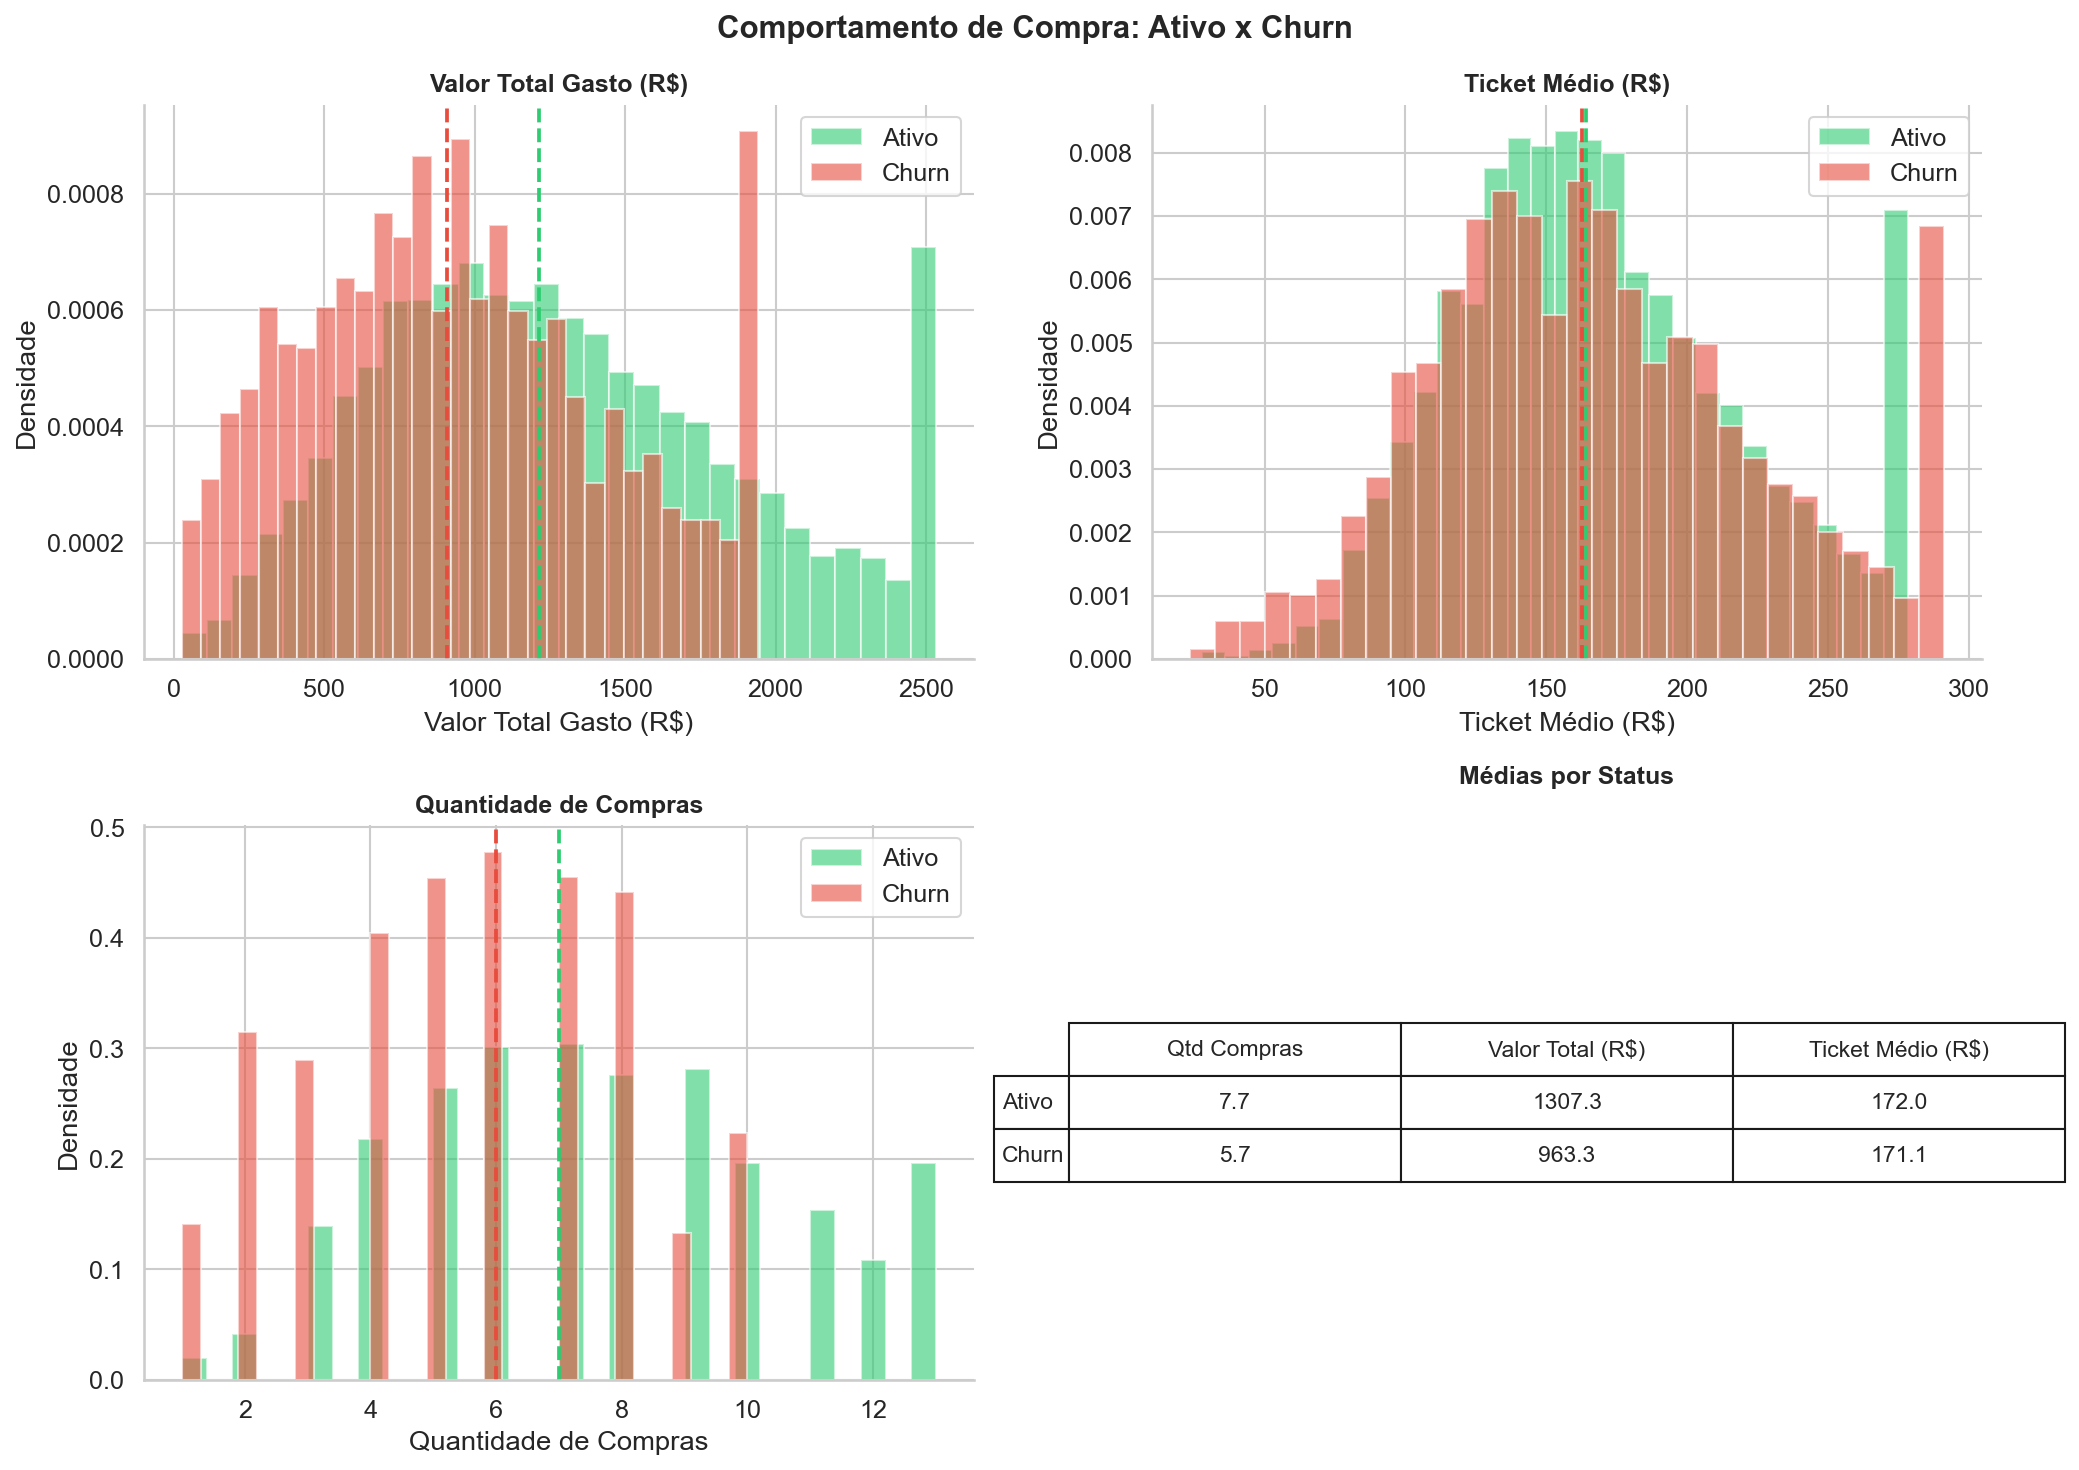

Médias por Status de Churn
       qtd_compras  valor_total  ticket_medio
Ativo         7.67      1307.30        172.02
Churn         5.68       963.26        171.09


In [7]:
compras = transacoes.groupby('id_cliente').agg(
    qtd_compras   =('valor', 'count'),
    valor_total   =('valor', 'sum'),
    ticket_medio  =('valor', 'mean'),
).reset_index()

clientes_comp = clientes.merge(compras, on='id_cliente', how='left')
clientes_comp['qtd_compras']  = clientes_comp['qtd_compras'].fillna(0)
clientes_comp['valor_total']  = clientes_comp['valor_total'].fillna(0)
clientes_comp['ticket_medio'] = clientes_comp['ticket_medio'].fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comportamento de Compra: Ativo x Churn', fontsize=15, fontweight='bold')

for ax, col, titulo in [
    (axes[0,0], 'valor_total',  'Valor Total Gasto (R$)'),
    (axes[0,1], 'ticket_medio', 'Ticket Médio (R$)'),
    (axes[1,0], 'qtd_compras',  'Quantidade de Compras'),
]:
    for label, cor in [(0, COR_OK), (1, COR_CHURN)]:
        nome = 'Ativo' if label == 0 else 'Churn'
        sub  = clientes_comp[clientes_comp['churn'] == label][col]
        lim  = sub.quantile(0.95)  # truncar outliers para visualização
        ax.hist(sub.clip(upper=lim), bins=30, alpha=0.6, color=cor,
                label=nome, density=True)
        ax.axvline(sub.median(), color=cor, linestyle='--', linewidth=1.8)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Densidade')
    ax.legend()

# Resumo comparativo
ax = axes[1, 1]
ax.axis('off')
resumo = clientes_comp.groupby('churn')[['qtd_compras','valor_total','ticket_medio']].mean()
resumo.index = ['Ativo', 'Churn']
tabela = ax.table(
    cellText=resumo.round(1).values,
    rowLabels=resumo.index,
    colLabels=['Qtd Compras', 'Valor Total (R$)', 'Ticket Médio (R$)'],
    cellLoc='center', loc='center'
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.2, 2)
ax.set_title('Médias por Status', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
save_fig('04_comportamento_compra')

print('Médias por Status de Churn')
print(resumo.round(2).to_string())

## **Análise Temporal:**

Salvo: ..\figures\05_analise_temporal.png


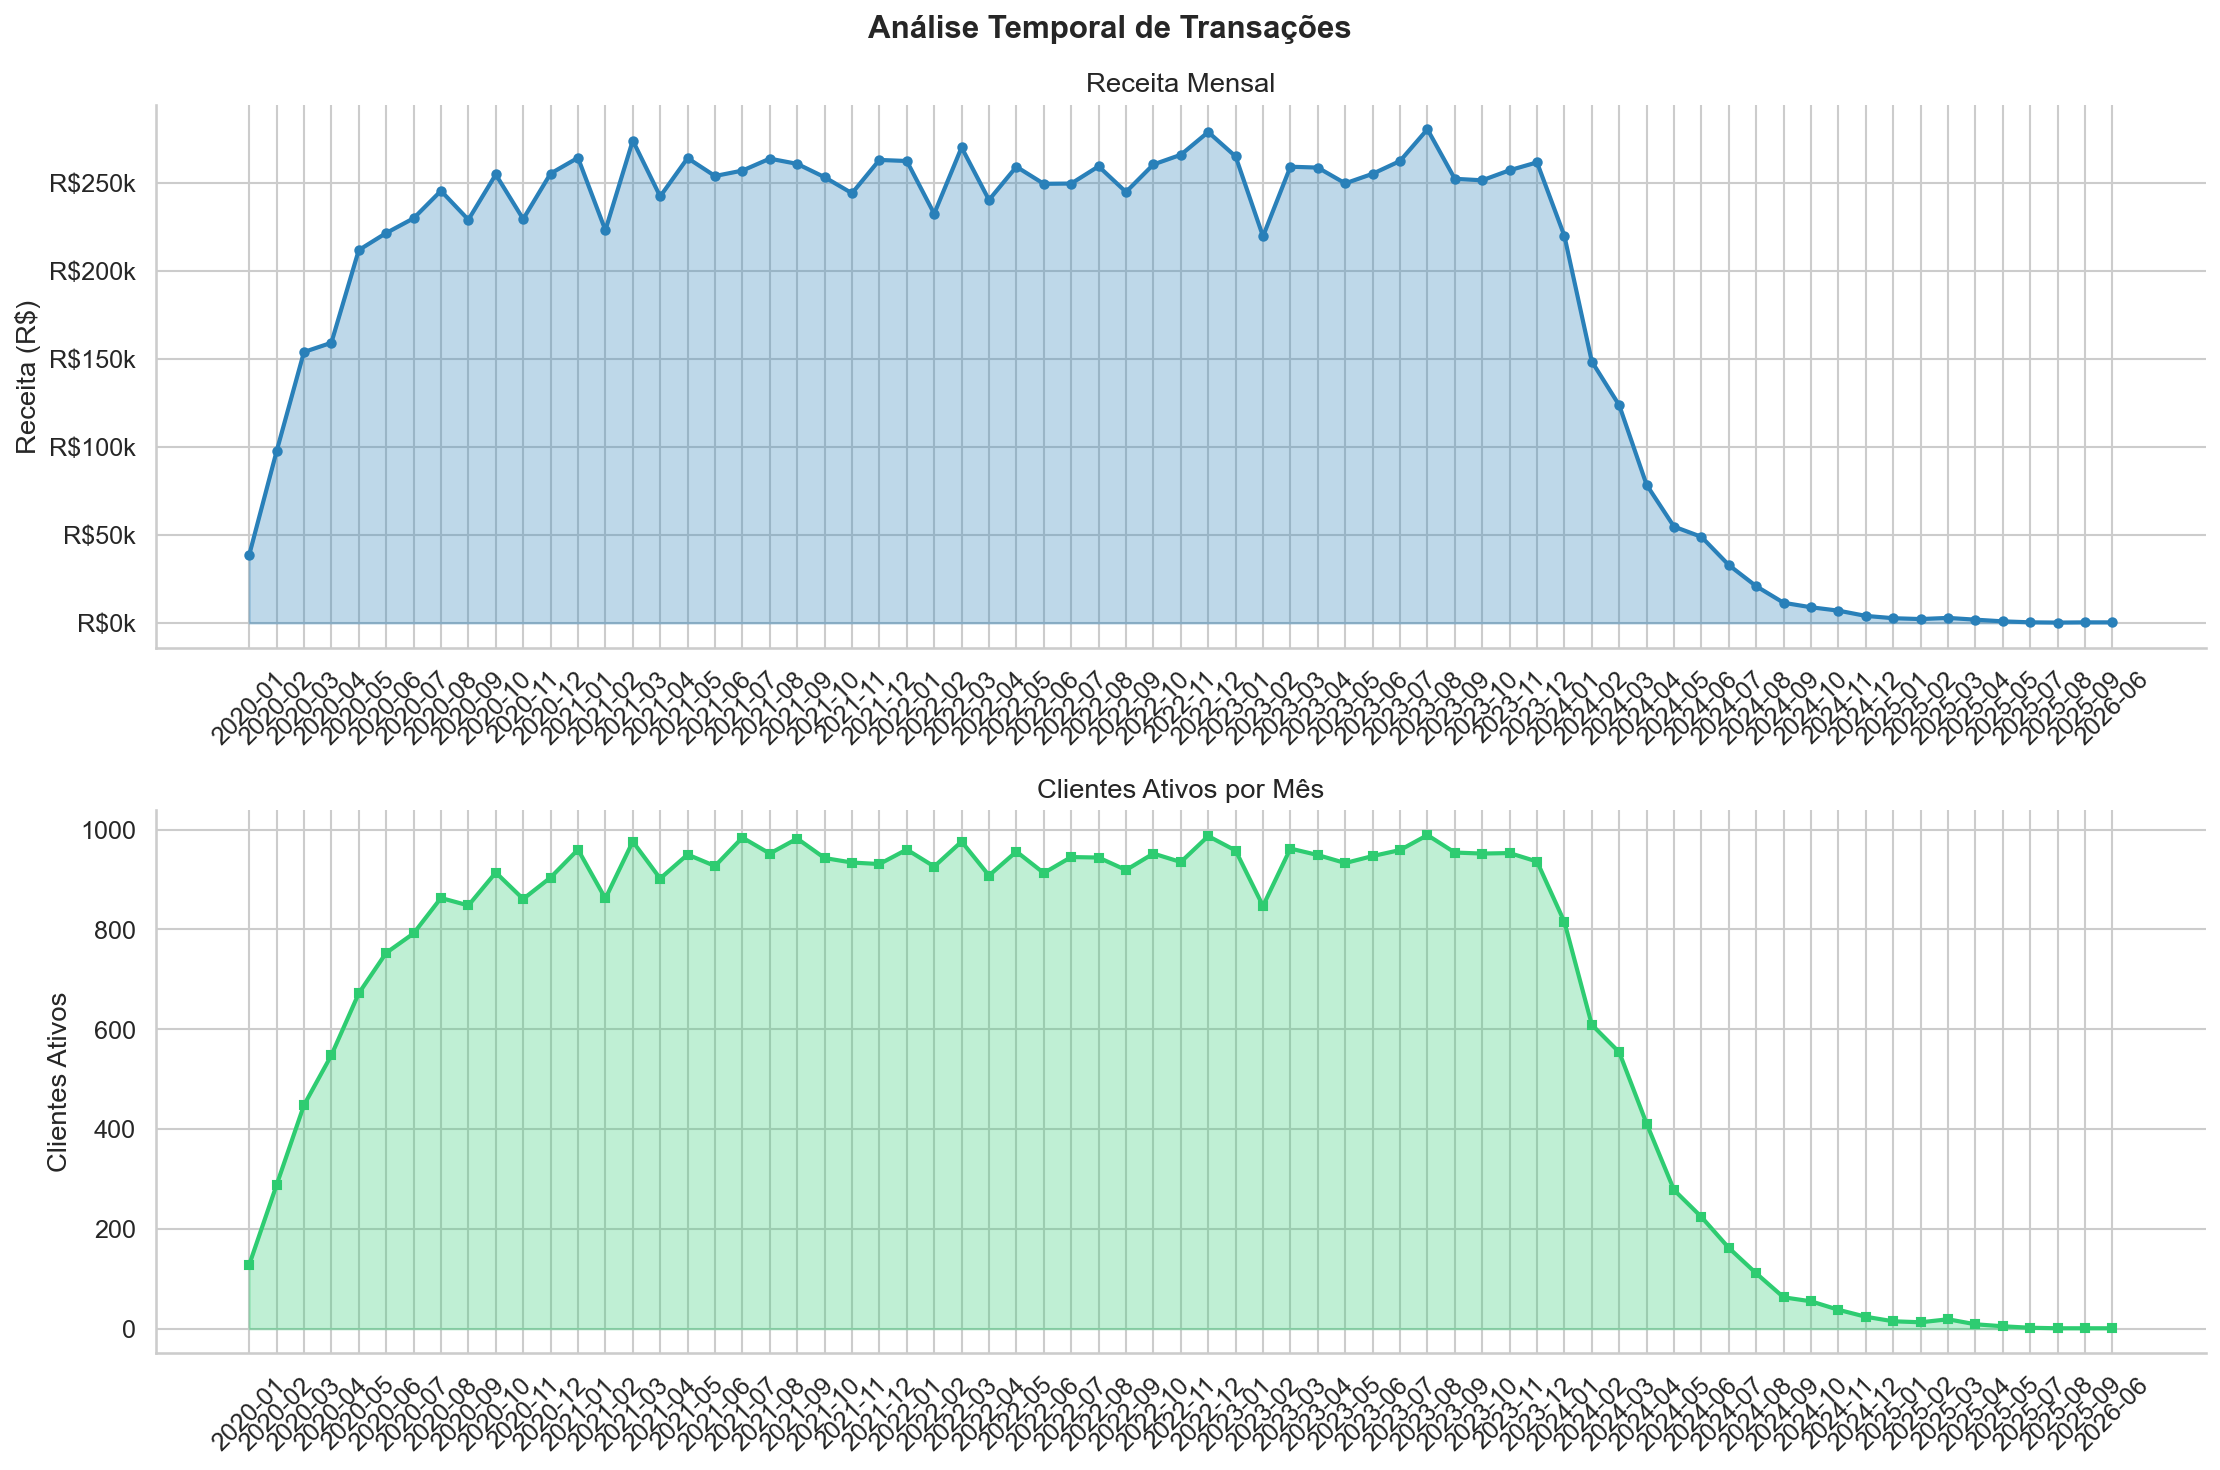

In [8]:
transacoes['mes_ano'] = transacoes['data_compra'].dt.to_period('M')
vendas_mensais = transacoes.groupby('mes_ano').agg(
    receita        =('valor', 'sum'),
    clientes_ativos=('id_cliente', 'nunique'),
    ticket_medio   =('valor', 'mean'),
).reset_index()
vendas_mensais['mes_ano'] = vendas_mensais['mes_ano'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Análise Temporal de Transações', fontsize=15, fontweight='bold')

ax = axes[0]
ax.fill_between(vendas_mensais['mes_ano'], vendas_mensais['receita'],
                alpha=0.3, color=COR_ACCENT)
ax.plot(vendas_mensais['mes_ano'], vendas_mensais['receita'],
        marker='o', linewidth=2, color=COR_ACCENT, markersize=4)
ax.set_ylabel('Receita (R$)')
ax.set_title('Receita Mensal')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))

ax = axes[1]
ax.fill_between(vendas_mensais['mes_ano'], vendas_mensais['clientes_ativos'],
                alpha=0.3, color=COR_OK)
ax.plot(vendas_mensais['mes_ano'], vendas_mensais['clientes_ativos'],
        marker='s', linewidth=2, color=COR_OK, markersize=4)
ax.set_ylabel('Clientes Ativos')
ax.set_title('Clientes Ativos por Mês')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('05_analise_temporal')

## **Churn por Categoria de Produto:**

Salvo: ..\figures\06_churn_categoria.png


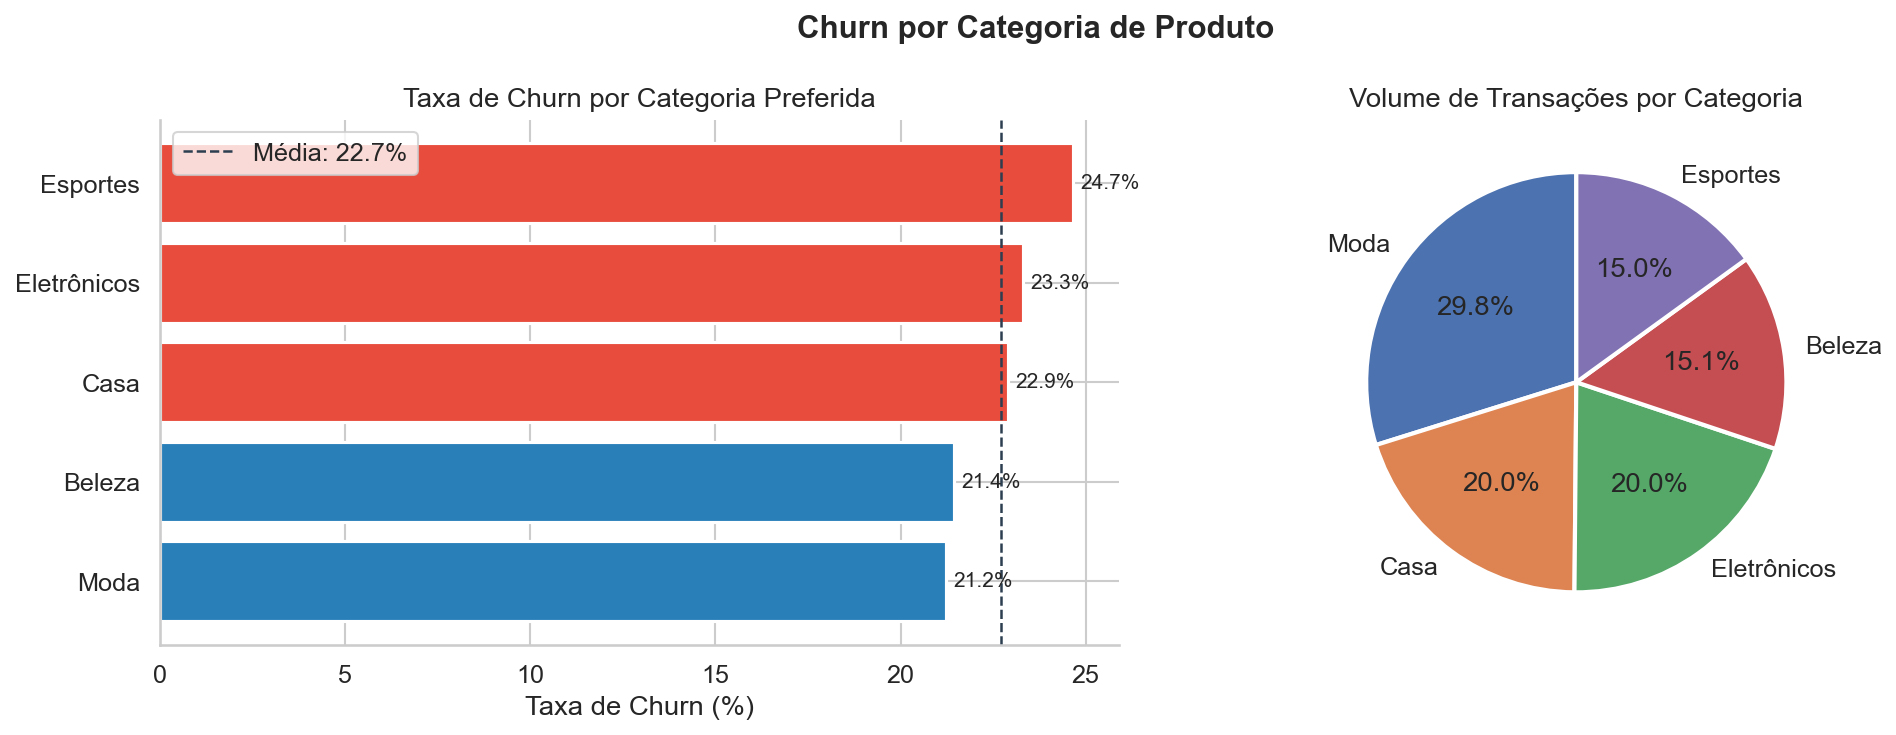

In [9]:
# Categoria mais comprada por cliente
cat_pref = transacoes.groupby(['id_cliente','categoria']).size()\
           .reset_index(name='n')\
           .sort_values('n', ascending=False)\
           .drop_duplicates('id_cliente')\
           .rename(columns={'categoria': 'cat_preferida'})

clientes_cat = clientes.merge(cat_pref[['id_cliente','cat_preferida']],
                               on='id_cliente', how='left')
clientes_cat['cat_preferida'] = clientes_cat['cat_preferida'].fillna('Sem compras')

churn_cat = clientes_cat.groupby('cat_preferida')['churn'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn por Categoria de Produto', fontsize=15, fontweight='bold')

ax = axes[0]
churn_cat_sorted = churn_cat.sort_values(ascending=True)
cores = [COR_CHURN if v > churn_cat.mean() else COR_ACCENT
         for v in churn_cat_sorted.values]
ax.barh(churn_cat_sorted.index, churn_cat_sorted.values,
        color=cores, edgecolor='white', linewidth=1.5)
ax.axvline(churn_cat.mean(), color=COR_NEUTRO, linestyle='--', linewidth=1.2,
           label=f'Média: {churn_cat.mean():.1f}%')
for i, val in enumerate(churn_cat_sorted.values):
    ax.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Taxa de Churn (%)')
ax.set_title('Taxa de Churn por Categoria Preferida')
ax.legend()

ax = axes[1]
volume_cat = transacoes['categoria'].value_counts()
ax.pie(volume_cat.values, labels=volume_cat.index,
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Volume de Transações por Categoria')

plt.tight_layout()
save_fig('06_churn_categoria')

## **Resumo dos Insights:**

In [10]:
taxa_geral    = clientes['churn'].mean() * 100
melhor_canal  = churn_canal.idxmin()
pior_canal    = churn_canal.idxmax()
melhor_cidade = churn_cidade.idxmin()
pior_cidade   = churn_cidade.idxmax()
media_compras_ativo = clientes_comp[clientes_comp['churn']==0]['qtd_compras'].mean()
media_compras_churn = clientes_comp[clientes_comp['churn']==1]['qtd_compras'].mean()
melhor_faixa  = churn_faixa.idxmin()
pior_faixa    = churn_faixa.idxmax()

print(f"""
╔══════════════════════════════════════════════════════════════╗
║           PRINCIPAIS INSIGHTS DA EDA                         ║
╠══════════════════════════════════════════════════════════════╣
║  Taxa de churn geral     : {taxa_geral:.2f}%                        ║
╠══════════════════════════════════════════════════════════════╣
║  CANAIS DE AQUISIÇÃO                                         ║
║   Melhor (menor churn)   : {melhor_canal:<12} ({churn_canal[melhor_canal]:.1f}%)         ║
║   Pior (maior churn)     : {pior_canal:<12} ({churn_canal[pior_canal]:.1f}%)        ║
╠══════════════════════════════════════════════════════════════╣
║  CIDADES                                                     ║
║   Melhor cidade          : {melhor_cidade:<12} ({churn_cidade[melhor_cidade]:.1f}%)        ║
║   Pior cidade            : {pior_cidade:<12} ({churn_cidade[pior_cidade]:.1f}%)        ║
╠══════════════════════════════════════════════════════════════╣
║  COMPORTAMENTO DE COMPRA                                     ║
║   Média compras (ativo)  : {media_compras_ativo:.1f}                          ║
║   Média compras (churn)  : {media_compras_churn:.1f}                          ║
║   → Engajar até a {media_compras_churn:.0f}ª compra é ponto crítico         ║
╠══════════════════════════════════════════════════════════════╣
║  FAIXA ETÁRIA                                                ║
║   Menor risco            : {melhor_faixa} anos ({churn_faixa[melhor_faixa]:.1f}%)       ║
║   Maior risco            : {pior_faixa} anos ({churn_faixa[pior_faixa]:.1f}%)       ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           PRINCIPAIS INSIGHTS DA EDA                         ║
╠══════════════════════════════════════════════════════════════╣
║  Taxa de churn geral     : 22.26%                        ║
╠══════════════════════════════════════════════════════════════╣
║  CANAIS DE AQUISIÇÃO                                         ║
║   Melhor (menor churn)   : Indicação    (9.2%)         ║
║   Pior (maior churn)     : Facebook     (33.7%)        ║
╠══════════════════════════════════════════════════════════════╣
║  CIDADES                                                     ║
║   Melhor cidade          : SP           (14.5%)        ║
║   Pior cidade            : BSB          (36.3%)        ║
╠══════════════════════════════════════════════════════════════╣
║  COMPORTAMENTO DE COMPRA                                     ║
║   Média compras (ativo)  : 7.7                          ║
║   Média compras (churn)  : 5.7                         